<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/Monte-Carlo-Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

<h1> One Simualtion </h1>

In [ ]:
avg = 1
std = .1
num_reps = 500
num_simulations = 1000
pct_to_target = np.random.normal(avg, std, size=num_reps).round(2)

pct_to_target[:10]

array([1.04, 0.92, 0.96, 0.93, 1.16, 0.94, 0.88, 1.23, 1.05, 1.02])

In [ ]:
sales_target_values = [75_000, 100_000, 200_000, 300_000, 400_000, 500_000]
sales_target_prob = [.3, .3, .2, .1, .05, .05]
sales_target = np.random.choice(sales_target_values, num_reps, p=sales_target_prob)

In [ ]:
df = pd.DataFrame(index=range(num_reps), data={'Pct_To_Target': pct_to_target,
                                               'Sales_Target': sales_target})
df['Sales'] = df['Pct_To_Target'] * df['Sales_Target']

df.head(5)

,Pct_To_Target,Sales_Target,Sales
0,1.04,200000,208000.0
1,0.92,75000,69000.0
2,0.96,100000,96000.0
3,0.93,400000,372000.0
4,1.16,100000,116000.0


In [ ]:
def calc_commission_rate(x):
  """Return commission rate based on table:
  0-90% = 2%
  91-99% = 3%
  >= 100% = 4%"""
  if x <= .9:
    return .02
  elif x <= .99:
    return .03
  else:
    return .04

In [ ]:
df['Commission_Rate'] = df['Pct_To_Target'].apply(calc_commission_rate)
df['Commission_Amount'] = df['Commission_Rate'] * df['Sales']

df

,Pct_To_Target,Sales_Target,Sales,Commission_Rate,Commission_Amount
0,1.04,200000,208000.0,0.04,8320.0
1,0.92,75000,69000.0,0.03,2070.0
2,0.96,100000,96000.0,0.03,2880.0
3,0.93,400000,372000.0,0.03,11160.0
4,1.16,100000,116000.0,0.04,4640.0
...,...,...,...,...,...
495,1.08,75000,81000.0,0.04,3240.0
496,0.99,75000,74250.0,0.03,2227.5
497,0.99,300000,297000.0,0.03,8910.0
498,1.06,100000,106000.0,0.04,4240.0


In [ ]:
print("Total Commission Amount: ", sum(df['Commission_Amount']))

Total Commission Amount:  2935305.0


<h1> Now for Monte Carlo Simulation: Pay Attention to # of simulations </h1>

In [ ]:
# define number of simulations
num_simulations = 100000
# list to keep all results from each simulation
all_stats =[]

# loop through many simulations
for i in range(num_simulations):
  # choose random inputs for the sales targets and percent to target
  sales_target = np.random.choice(sales_target_values, num_reps, p=sales_target_prob)
  pct_to_target = np.random.normal(avg, std, num_reps).round(2)

  # build the dataframe based on inputs and number of reps
  df = pd.DataFrame(index=range(num_reps), data={'Pct_To_Target': pct_to_target,
                                                 'Sales_Target': sales_target})

  # back into the sales number using the precent to target rate
  df['Sales'] = df['Pct_To_Target'] * df['Sales_Target']

  # determine the commissions rate and calculate it
  df['Commission_Rate'] = df['Pct_To_Target'].apply(calc_commission_rate)
  df['Commission_Amount'] = df['Commission_Rate'] * df['Sales']

  # track sales, commission amounts, and sales targets over all the simulations
  all_stats.append([df['Sales'].sum().round(0),
                   df['Commission_Amount'].sum().round(0),
                   df['Sales_Target'].sum().round(0)])

In [ ]:
results = pd.DataFrame.from_records(all_stats, columns=['Sales',
                                                        'Commission_Amount',
                                                        'Sales_Target'])

In [ ]:
results.describe().style.format('{:,}')

,Sales,Commission_Amount,Sales_Target
count,"100,000.0","100,000.0","100,000.0"
mean,"83,756,373.0125","2,859,689.85775","83,755,954.5"
std,"2,705,343.67803387","102,422.06106868514","2,665,397.479713858"
min,"71,455,250.0","2,389,600.0","71,875,000.0"
25%,"81,918,000.0","2,789,551.5","81,950,000.0"
50%,"83,732,750.0","2,858,434.0","83,725,000.0"
75%,"85,547,812.5","2,927,835.0","85,525,000.0"
max,"96,278,000.0","3,324,052.0","95,875,000.0"


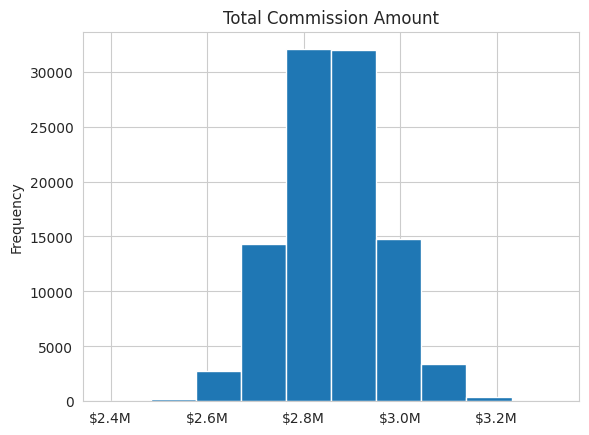

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ax = results['Commission_Amount'].plot(
    kind='hist',
    title='Total Commission Amount'
)

def millions(x, pos):
    return f'${x/1_000_000:.1f}M'

ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.show()